In [1]:
import pandas as pd 
import numpy as np 

from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split



In [2]:
data = pd.read_csv("C:\\Users\\bingi\\Downloads\\car details v4.csv")
df = data.copy()
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [3]:
df.shape

(2059, 20)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,2059.0,1.702992e+06,2.419881e+06,49000.0,484999.00,825000.0,1925000.0,35000000.0
Year,2059.0,2.016425e+03,3.363564e+00,1988.0,2014.00,2017.0,2019.0,2022.0
Kilometer,2059.0,5.422471e+04,5.736172e+04,0.0,29000.00,50000.0,72000.0,2000000.0
Length,1995.0,4.280861e+03,4.424585e+02,3099.0,3985.00,4370.0,4629.0,5569.0
Width,1995.0,1.767992e+03,1.352658e+02,1475.0,1695.00,1770.0,1831.5,2220.0
Height,1995.0,1.591735e+03,1.360740e+02,1165.0,1485.00,1545.0,1675.0,1995.0
Seating Capacity,1995.0,5.306266e+00,8.221701e-01,2.0,5.00,5.0,5.0,8.0
Fuel Tank Capacity,1946.0,5.200221e+01,1.511020e+01,15.0,41.25,50.0,60.0,105.0


In [5]:
df.columns

Index(['Make', 'Model', 'Price', 'Year', 'Kilometer', 'Fuel Type',
       'Transmission', 'Location', 'Color', 'Owner', 'Seller Type', 'Engine',
       'Max Power', 'Max Torque', 'Drivetrain', 'Length', 'Width', 'Height',
       'Seating Capacity', 'Fuel Tank Capacity'],
      dtype='object')

In [6]:
df.drop(['Model' , 'Color' , 'Seller Type'] , axis = 1 ,inplace = True)

In [7]:
df.drop_duplicates(inplace = True)

In [8]:
df_clean = df.copy()

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    # Filter out outliers for this column
    df_clean = df_clean[(df_clean[col] >= Q1 - 1.5*IQR) & (df_clean[col] <= Q3 + 1.5*IQR)]

print(df_clean.shape)


(1228, 17)


In [9]:
y = df_clean['Price']    # Target

X = df_clean.drop(columns='Price' , axis = 1)    # Features

In [10]:
num_cols = X.select_dtypes(include = 'number').columns.to_list()
cat_cols = X.select_dtypes(exclude = 'number').columns.to_list()

print(num_cols)
print(cat_cols)

['Year', 'Kilometer', 'Length', 'Width', 'Height', 'Seating Capacity', 'Fuel Tank Capacity']
['Make', 'Fuel Type', 'Transmission', 'Location', 'Owner', 'Engine', 'Max Power', 'Max Torque', 'Drivetrain']


In [11]:
num_transformations = Pipeline(steps=[('imputer' , SimpleImputer(strategy='mean')),
                                      ('Scaling' , StandardScaler())])

col_transformations = Pipeline(steps = [('imputer' , SimpleImputer(strategy='most_frequent')),
                                        ('encoding' , OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers = [('num' , num_transformations , num_cols),
                                                 ('col' , col_transformations , cat_cols)],
                                                 remainder = 'passthrough')
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('col', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)


In [13]:
model = LinearRegression()
final_pipeline = Pipeline([('preprocessor' , preprocessor) , ('model' , model)])
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('col', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [14]:
final_pipeline.fit(X_train , y_train)
y_pred = final_pipeline.predict(X_train)
print('Predictions:',y_pred)

Predictions: [1072865.48456661 2118063.94462926 2044896.86858979  950046.09586309
  703697.16270646  468207.03146354  648012.24075881  562079.45922324
  649779.14385063  447121.74819831 1716545.77942429  905352.80726113
  920233.09132152  213475.91313164 2067053.60060074 1495759.71724476
  643938.85177795  342625.98926318  602459.5437798   959465.30370241
  719972.25994332   80089.06727534  367975.44474714 1501854.06357631
 1514210.09829963  425111.09034114  709805.73994316 1057903.32677006
  345005.79023865  546941.61287019 2729541.09238442 1410247.00835814
  889726.55478005  430835.56585045  391821.48683036 1462930.19515482
  559981.37199864 1086450.16710862  782838.96351605  635437.42040685
 1547266.33124952 2474077.27994198 1471200.58942683  806913.92178517
  767660.10749155 2800489.68033133  949459.02261298 1994815.26614723
  680115.35633359 1211249.03816025 1410705.77436259  745115.04053356
  310759.49762128  651592.67911754  248733.91535476 2504138.59092361
  609194.18081     21

In [15]:
print('mean_squared_error:' , mean_squared_error(y_train,y_pred))
print('root_mean_squared_error:' ,np.sqrt(mean_squared_error(y_train , y_pred)))
print('accuracy:' , r2_score(y_train,y_pred))

mean_squared_error: 19653801876.396893
root_mean_squared_error: 140192.01787689945
accuracy: 0.9640680867338568


In [16]:
for actual , predict in zip(y_train , y_pred):
    print(f'y_train: {actual} vs y_pred: {predict}')

y_train: 1100000 vs y_pred: 1072865.4845666054
y_train: 1825000 vs y_pred: 2118063.944629265
y_train: 1995000 vs y_pred: 2044896.8685897877
y_train: 950000 vs y_pred: 950046.0958630929
y_train: 395000 vs y_pred: 703697.162706457
y_train: 425000 vs y_pred: 468207.03146354423
y_train: 550000 vs y_pred: 648012.2407588077
y_train: 600000 vs y_pred: 562079.4592232396
y_train: 755000 vs y_pred: 649779.1438506265
y_train: 525000 vs y_pred: 447121.748198305
y_train: 1775000 vs y_pred: 1716545.779424286
y_train: 865000 vs y_pred: 905352.8072611289
y_train: 775000 vs y_pred: 920233.0913215248
y_train: 335000 vs y_pred: 213475.91313164285
y_train: 1950000 vs y_pred: 2067053.6006007376
y_train: 1399000 vs y_pred: 1495759.7172447643
y_train: 545000 vs y_pred: 643938.8517779524
y_train: 315000 vs y_pred: 342625.9892631755
y_train: 575000 vs y_pred: 602459.5437797989
y_train: 869999 vs y_pred: 959465.3037024145
y_train: 720000 vs y_pred: 719972.2599433224
y_train: 185000 vs y_pred: 80089.06727533601


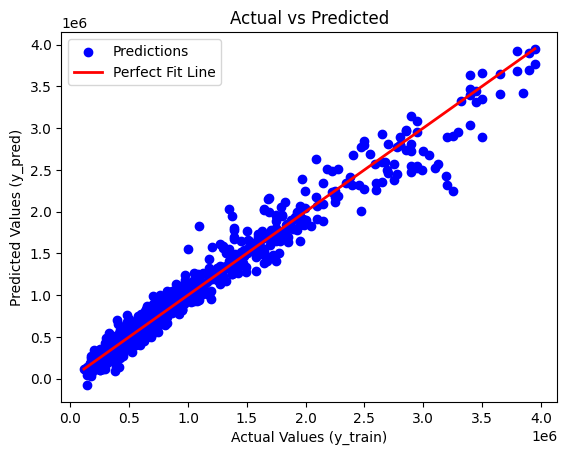

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_train, y_pred, color='blue', label='Predictions')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
         color='red', linewidth=2, label='Perfect Fit Line')

plt.xlabel("Actual Values (y_train)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()


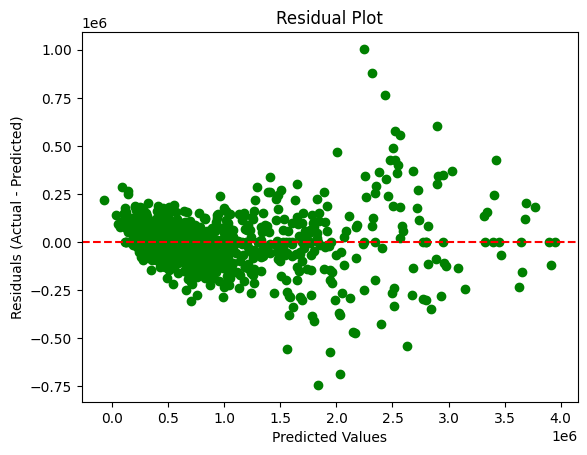

In [18]:
residuals = y_train - y_pred

plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()


In [19]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

# Define models with key parameters
models = {
    'LinearRegression': LinearRegression(
        fit_intercept=True,   # whether to calculate bias term
        copy_X=True,          # copy input data
        n_jobs=None           # parallel jobs (None = 1 core)
    ),
    
    'LassoRegression': Lasso(
        alpha=1.0,            # regularization strength (L1 penalty)
        fit_intercept=True,   # include bias term
        max_iter=1000,        # max iterations for solver
        tol=1e-4,             # tolerance for stopping
        selection='cyclic'    # update strategy: 'cyclic' or 'random'
    ),
    
    'RidgeRegression': Ridge(
        alpha=1.0,            # regularization strength (L2 penalty)
        fit_intercept=True,   # include bias term
        solver='auto',        # solver choice
        max_iter=None,        # max iterations (for iterative solvers)
        tol=1e-3              # tolerance for stopping
    )
}


In [20]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np

results = {}

for name, model in models.items():
    print('\nRunning model:', name)
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Store all metrics together in a dictionary
    results[name] = {
        'mean_squared_error': mean_squared_error(y_test, y_pred),
        'root_mean_squared_error': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2_score': r2_score(y_test, y_pred)
    }

# Print results neatly
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    print("Mean Squared Error:", metrics['mean_squared_error'])
    print("Root Mean Squared Error:", metrics['root_mean_squared_error'])
    print("R² Score:", metrics['r2_score'])



Running model: LinearRegression

Running model: LassoRegression

Running model: RidgeRegression

Model: LinearRegression
Mean Squared Error: 49554102904.24687
Root Mean Squared Error: 222607.50864300798
R² Score: 0.9042226437493958

Model: LassoRegression
Mean Squared Error: 41130895107.02253
Root Mean Squared Error: 202807.5321752684
R² Score: 0.920502881442862

Model: RidgeRegression
Mean Squared Error: 55138968378.759964
Root Mean Squared Error: 234816.88265275978
R² Score: 0.8934283074822711


c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.051e+12, tolerance: 5.371e+10
  model = cd_fast.sparse_enet_coordinate_descent(


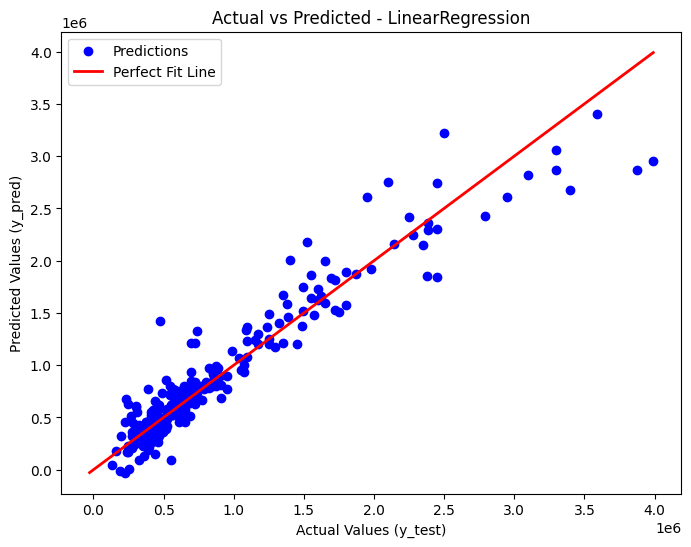

c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.051e+12, tolerance: 5.371e+10
  model = cd_fast.sparse_enet_coordinate_descent(


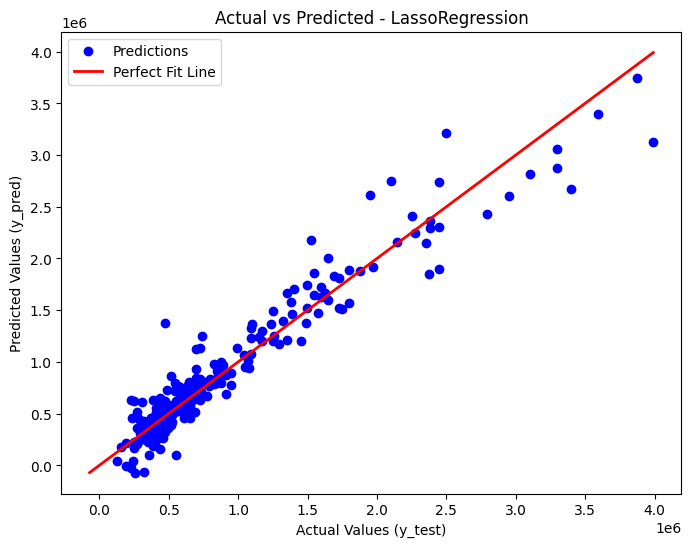

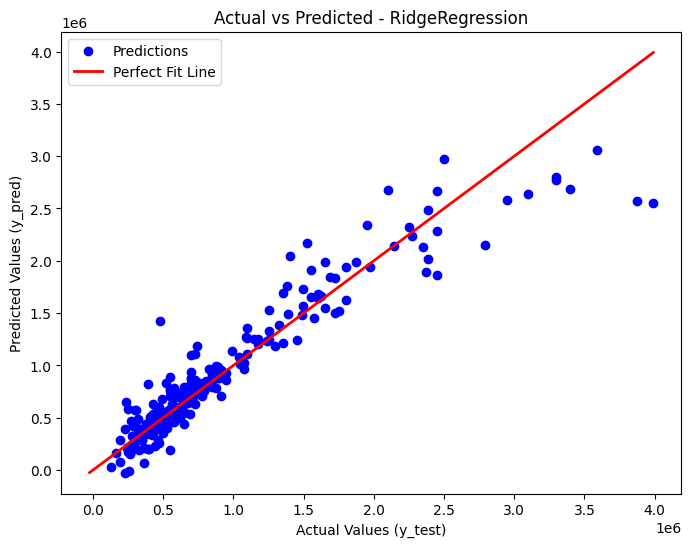

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Loop through each model
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Create a new figure for each model
    plt.figure(figsize=(8,6))

    plt.scatter(y_test , y_pred , color = 'blue' , label = 'Predictions')

    min_val = min(y_test.min() , y_pred.min())
    max_val = max(y_test.max() , y_pred.max())
    
    plt.plot([min_val,max_val] , [min_val , max_val] , color = 'red' , linewidth = 2 , label = 'Perfect Fit Line')
    
    plt.title(f"Actual vs Predicted - {name}")
    plt.xlabel("Actual Values (y_test)")
    plt.ylabel("Predicted Values (y_pred)")
    plt.legend()
    plt.show()



In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

LinearRegression(
    fit_intercept=True,     # Whether to include bias (intercept) term
    copy_X=True,            # Copy input data; avoids overwriting original
    n_jobs=None             # Number of CPU cores for computation (None = 1)
)

Lasso(
    alpha=1.0,              # Regularization strength (L1 penalty); higher = stronger shrinkage
    fit_intercept=True,     # Whether to include bias (intercept) term
    max_iter=1000,          # Maximum iterations for convergence
    selection='cyclic'      # Coordinate descent order (cyclic or random)
)

Ridge(
    alpha=1.0,              # Regularization strength (L2 penalty)
    fit_intercept=True,     # Whether to include bias (intercept) term
    solver='auto',          # Algorithm chosen automatically based on data
    max_iter=1000           # Maximum iterations for convergence
)

LogisticRegression(
    C=0.5,                      # Inverse of regularization strength; smaller = stronger penalty
    class_weight='balanced',    # Adjusts weights inversely proportional to class frequencies
    solver='lbfgs',             # Optimization algorithm (good for small/medium datasets)
    max_iter=1000               # Maximum iterations for convergence
)

RandomForestClassifier(
    n_estimators=100,           # Number of trees in the forest
    max_depth=10,               # Maximum depth of each tree
    min_samples_split=4,        # Minimum samples required to split a node
    min_samples_leaf=2,         # Minimum samples required at a leaf node
    max_features='sqrt',        # Number of features considered at each split
    bootstrap=True,             # Whether to sample with replacement
    random_state=42             # Seed for reproducibility
)

SVC(
    C=1.0,                      # Regularization parameter; higher = less regularization
    kernel='linear',            # Kernel type (linear decision boundary)
    gamma='scale',              # Kernel coefficient (auto‑scaled for data)
    probability=True,           # Enable probability estimates via Platt scaling
    class_weight='balanced',    # Adjusts weights inversely proportional to class frequencies
    max_iter=1000               # Maximum iterations for convergence
)

KNeighborsClassifier(
    n_neighbors=5,              # Number of nearest neighbors
    weights='distance',         # Weight by distance (closer neighbors = more influence)
    metric='minkowski',         # Distance metric (generalized form)
    p=2                         # Power parameter (p=2 → Euclidean, p=1 → Manhattan)
)

DecisionTreeClassifier(
    max_depth=10,               # Maximum depth of the tree
    min_samples_split=4,        # Minimum samples required to split a node
    min_samples_leaf=2,         # Minimum samples required at a leaf node
    criterion='gini',           # Function to measure split quality (Gini impurity)
    splitter='best',            # Strategy to choose split at each node
    class_weight='balanced'     # Adjusts weights inversely proportional to class frequencies
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [25]:
df.head()

,Make,Price,Year,Kilometer,Fuel Type,Transmission,Location,Owner,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,505000,2017,87150,Petrol,Manual,Pune,First,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,450000,2014,75000,Diesel,Manual,Ludhiana,Second,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,220000,2011,67000,Petrol,Manual,Lucknow,First,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,799000,2019,37500,Petrol,Manual,Mangalore,First,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,1950000,2018,69000,Diesel,Manual,Mumbai,First,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [26]:
import pandas as pd

# ✅ New input data (10 rows, no Price column)
new_data = pd.DataFrame([
    {
        "Make": "Honda", "Year": 2017, "Kilometer": 87150, "Fuel Type": "Petrol",
        "Transmission": "Manual", "Location": "Pune", "Owner": "First",
        "Engine": 1198, "Max Power": 87, "Max Torque": 109, "Drivetrain": "FWD",
        "Length": 3990, "Width": 1680, "Height": 1505, "Seating Capacity": 5,
        "Fuel Tank Capacity": 35
    },
    {
        "Make": "Maruti Suzuki", "Year": 2014, "Kilometer": 75000, "Fuel Type": "Diesel",
        "Transmission": "Manual", "Location": "Ludhiana", "Owner": "Second",
        "Engine": 1248, "Max Power": 74, "Max Torque": 190, "Drivetrain": "FWD",
        "Length": 3995, "Width": 1695, "Height": 1555, "Seating Capacity": 5,
        "Fuel Tank Capacity": 42
    },
    {
        "Make": "Hyundai", "Year": 2011, "Kilometer": 67000, "Fuel Type": "Petrol",
        "Transmission": "Manual", "Location": "Lucknow", "Owner": "First",
        "Engine": 1197, "Max Power": 79, "Max Torque": 113, "Drivetrain": "FWD",
        "Length": 3585, "Width": 1595, "Height": 1550, "Seating Capacity": 5,
        "Fuel Tank Capacity": 35
    },
    {
        "Make": "Toyota", "Year": 2019, "Kilometer": 37500, "Fuel Type": "Petrol",
        "Transmission": "Manual", "Location": "Mangalore", "Owner": "First",
        "Engine": 1197, "Max Power": 82, "Max Torque": 113, "Drivetrain": "FWD",
        "Length": 3995, "Width": 1745, "Height": 1510, "Seating Capacity": 5,
        "Fuel Tank Capacity": 37
    },
    {
        "Make": "Toyota", "Year": 2018, "Kilometer": 69000, "Fuel Type": "Diesel",
        "Transmission": "Manual", "Location": "Mumbai", "Owner": "First",
        "Engine": 2393, "Max Power": 148, "Max Torque": 343, "Drivetrain": "RWD",
        "Length": 4735, "Width": 1830, "Height": 1795, "Seating Capacity": 7,
        "Fuel Tank Capacity": 55
    },
    {
        "Make": "Hyundai", "Year": 2020, "Kilometer": 30000, "Fuel Type": "Diesel",
        "Transmission": "Automatic", "Location": "Bangalore", "Owner": "Second",
        "Engine": 1493, "Max Power": 115, "Max Torque": 250, "Drivetrain": "FWD",
        "Length": 4300, "Width": 1790, "Height": 1550, "Seating Capacity": 5,
        "Fuel Tank Capacity": 50
    },
    {
        "Make": "Tata", "Year": 2019, "Kilometer": 25000, "Fuel Type": "Electric",
        "Transmission": "Automatic", "Location": "Mumbai", "Owner": "First",
        "Engine": 0, "Max Power": 127, "Max Torque": 245, "Drivetrain": "FWD",
        "Length": 3990, "Width": 1810, "Height": 1600, "Seating Capacity": 5,
        "Fuel Tank Capacity": 0
    },
    {
        "Make": "Mahindra", "Year": 2021, "Kilometer": 15000, "Fuel Type": "Diesel",
        "Transmission": "Manual", "Location": "Delhi", "Owner": "First",
        "Engine": 2184, "Max Power": 130, "Max Torque": 300, "Drivetrain": "RWD",
        "Length": 4500, "Width": 1850, "Height": 1700, "Seating Capacity": 7,
        "Fuel Tank Capacity": 60
    },
    {
        "Make": "Ford", "Year": 2016, "Kilometer": 82000, "Fuel Type": "Petrol",
        "Transmission": "Manual", "Location": "Kolkata", "Owner": "Second",
        "Engine": 1499, "Max Power": 110, "Max Torque": 140, "Drivetrain": "FWD",
        "Length": 4315, "Width": 1760, "Height": 1525, "Seating Capacity": 5,
        "Fuel Tank Capacity": 52
    },
    {
        "Make": "Nissan", "Year": 2015, "Kilometer": 95000, "Fuel Type": "Diesel",
        "Transmission": "Manual", "Location": "Jaipur", "Owner": "Third",
        "Engine": 1461, "Max Power": 85, "Max Torque": 200, "Drivetrain": "FWD",
        "Length": 4455, "Width": 1695, "Height": 1500, "Seating Capacity": 5,
        "Fuel Tank Capacity": 41
    }
])

print(new_data)


            Make  Year  Kilometer Fuel Type Transmission   Location   Owner  \
0          Honda  2017      87150    Petrol       Manual       Pune   First   
1  Maruti Suzuki  2014      75000    Diesel       Manual   Ludhiana  Second   
2        Hyundai  2011      67000    Petrol       Manual    Lucknow   First   
3         Toyota  2019      37500    Petrol       Manual  Mangalore   First   
4         Toyota  2018      69000    Diesel       Manual     Mumbai   First   
5        Hyundai  2020      30000    Diesel    Automatic  Bangalore  Second   
6           Tata  2019      25000  Electric    Automatic     Mumbai   First   
7       Mahindra  2021      15000    Diesel       Manual      Delhi   First   
8           Ford  2016      82000    Petrol       Manual    Kolkata  Second   
9         Nissan  2015      95000    Diesel       Manual     Jaipur   Third   

   Engine  Max Power  Max Torque Drivetrain  Length  Width  Height  \
0    1198         87         109        FWD    3990   1680  

In [27]:
# ✅ Correct way to predict on new data

for name, model in models.items():
    print(f"\nRunning model: {name}")
    
    # Build pipeline with preprocessor + model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Fit on training data
    pipeline.fit(X_train, y_train)
    
    # Predict on new unseen data
    new_pred = pipeline.predict(new_data)
    
    print(f"{name} Predictions:")
    for i, val in enumerate(new_pred, start=1):
        print(f"Row {i}: {val:.2f}")



Running model: LinearRegression
LinearRegression Predictions:
Row 1: 752550.41
Row 2: 365060.75
Row 3: -32375.90
Row 4: 968641.65
Row 5: 1513797.83
Row 6: 1616624.56
Row 7: 611693.19
Row 8: 1959390.45
Row 9: 790336.69
Row 10: 662504.96

Running model: LassoRegression
LassoRegression Predictions:
Row 1: 560864.37
Row 2: 234913.53
Row 3: -184030.13
Row 4: 805183.74
Row 5: 1378693.70
Row 6: 1492331.67
Row 7: 401615.04
Row 8: 1666910.22
Row 9: 572260.05
Row 10: 403229.06

Running model: RidgeRegression
RidgeRegression Predictions:
Row 1: 698493.57
Row 2: 425768.13
Row 3: -157701.25
Row 4: 938687.63
Row 5: 1740975.67
Row 6: 1666447.13
Row 7: 882340.51
Row 8: 2186851.58
Row 9: 710086.66
Row 10: 634858.04


c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.051e+12, tolerance: 5.371e+10
  model = cd_fast.sparse_enet_coordinate_descent(
